# uci_har_prototype_quantised.ipynb
## UCI HAR Baseline Prototype with Quantisation
##
### This notebook demonstrates:
#### 1. Loading and preprocessing UCI HAR dataset
#### 2. Feature extraction from raw sensor data
#### 3. Building and training a neural network for 6-class classification
#### 4. Reducing to 2-class (stationary vs walking) for on-device deployment
#### 5. Converting models to TFLite format with optional quantisation
#### 6. Saving models, scalers, and evaluation metrics

In [ ]:
# Install Dependencies

!pip install tensorflow-model-optimization
!pip install ai-edge-litert

In [ ]:
# Imports

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import math
import os
import tensorflow_model_optimization as tfmot
import json
import warnings


In [ ]:
# Suppress specific warnings for cleaner output
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    message=".*Statistics for quantized inputs were expected.*"
)

%matplotlib inline

In [ ]:


# Mount Google Drive and Setup Paths

from google.colab import drive

google_drive_path = "/content/drive"

# Mount Google Drive
drive.mount(google_drive_path, force_remount=True)

# Project custom drive path
my_path = "AG/FH/study/AI_IoT/node/milestone2"

# Declare project home directory
project_path = f"{google_drive_path}/MyDrive/{my_path}"
os.makedirs(project_path, exist_ok=True)

# Create output directories for models and evaluation results
## Full Features
os.makedirs(f"{project_path}/output/full_model", exist_ok=True)
os.makedirs(f"{project_path}/output/full_model/models", exist_ok=True)
## Reduced Features
os.makedirs(f"{project_path}/output/reduced", exist_ok=True)
os.makedirs(f"{project_path}/output/reduced/models", exist_ok=True)


In [ ]:
# Configuration and Reproducibility

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Class definitions for UCI HAR dataset (6 activities)
TARGET_NAMES = ["WALKING", "WALKING_UP", "WALKING_DOWN", "SITTING", "STANDING", "LAYING"]
NUM_CLASSES = 6

# Window parameters for feature extraction
WINDOW_SIZE = 128      # Number of samples per window (matches UCI HAR default)
WINDOW_STEP = 64       # Overlap between consecutive windows

In [ ]:
# Data Loading Functions

def load_uci_har_raw(data_path=f"{project_path}/UCI-HAR_Dataset"):
    """
    Load raw UCI HAR dataset from text files.

    Args:
        data_path: Path to the UCI HAR Dataset directory

    Returns:
        X_train: Training data array of shape (7352, 128, 6)
        y_train: Training labels array of shape (7352,)
        X_test: Test data array of shape (2947, 128, 6)
        y_test: Test labels array of shape (2947,)
    """
    # Sensor column definitions
    acc_axes = ["body_acc_x", "body_acc_y", "body_acc_z"]
    gyro_axes = ["body_gyro_x", "body_gyro_y", "body_gyro_z"]

    def _load_split(split):
        """Load a specific split (train or test) from the dataset."""
        arrays = []
        for name in acc_axes + gyro_axes:
            path = f"{data_path}/{split}/InertialSignals/{name}_{split}.txt"
            arrays.append(np.loadtxt(path))
        # Stack sensor data along last dimension
        return np.stack(arrays, axis=-1)

    # Load training and test data
    X_train = _load_split("train")
    X_test = _load_split("test")

    # Load labels (1-indexed, convert to 0-indexed)
    y_train = np.loadtxt(f"{data_path}/train/y_train.txt", dtype=int) - 1
    y_test = np.loadtxt(f"{data_path}/test/y_test.txt", dtype=int) - 1

    return X_train, y_train, X_test, y_test


def extract_features_window(window):
    """
    Extract statistical features from a single window of sensor data.

    Features extracted:
    - Mean and std for each of 6 axes (12 features)
    - Min and max for each of 6 axes (12 features)
    - Mean absolute acceleration (1 feature)
    - Mean absolute gyroscope (1 feature)
    - Acceleration magnitude mean and std (2 features)

    Args:
        window: 2D array of shape (window_size, 6) containing sensor readings

    Returns:
        1D array of extracted features (length 28)
    """
    features = []

    # 1. Mean and standard deviation for each axis
    for axis in range(6):
        features.append(np.mean(window[:, axis]))
        features.append(np.std(window[:, axis]))

    # 2. Min and max for each axis
    for axis in range(6):
        features.append(np.min(window[:, axis]))
        features.append(np.max(window[:, axis]))

    # 3. Mean absolute acceleration (first 3 axes: accelerometer)
    features.append(np.sum(np.abs(window[:, :3])) / window.shape[0])

    # 4. Mean absolute gyroscope (last 3 axes: gyroscope)
    features.append(np.sum(np.abs(window[:, 3:])) / window.shape[0])

    # 5. Acceleration magnitude (Euclidean norm across x, y, z)
    acc_magnitude = np.linalg.norm(window[:, :3], axis=1)
    features.append(np.mean(acc_magnitude))
    features.append(np.std(acc_magnitude))

    return np.array(features)


def extract_features_dataset(X_raw):
    """
    Extract features from the entire dataset.

    Args:
        X_raw: Raw data of shape (num_samples, window_size, num_sensors)

    Returns:
        Feature matrix of shape (num_samples, num_features)
    """
    features_list = []
    for window in X_raw:
        features_list.append(extract_features_window(window))
    return np.array(features_list)



In [ ]:
# Load and Process Full Dataset (6-Class)

print("\n" + "="*60)
print("UCI HAR Dataset Loading")
print("="*60)

# Load raw data
X_train_raw, y_train, X_test_raw, y_test = load_uci_har_raw()

print(f"Training data shape: {X_train_raw.shape}")
print(f"Test data shape: {X_test_raw.shape}")


In [ ]:
# Extract features from raw windows
X_train_feat = extract_features_dataset(X_train_raw)
X_test_feat = extract_features_dataset(X_test_raw)

print(f"\nExtracted features - train: {X_train_feat.shape}, test: {X_test_feat.shape}")

# Standardize features (zero mean, unit variance)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_feat)
X_test_scaled = scaler.transform(X_test_feat)

print(f"Scaled features - train: {X_train_scaled.shape}, test: {X_test_scaled.shape}")

In [ ]:
# Build and Train 6-Class Model

print("\n" + "="*60)
print("Building 6-Class Classification Model")
print("="*60)

# Define neural network architecture
complete_feature_model = models.Sequential([
    layers.Input(shape=(X_train_feat.shape[1],)),
    layers.Dense(32, activation="relu", name="dense_hidden"),
    layers.Dense(NUM_CLASSES, activation="softmax", name="dense_output"),
], name="complete_features_baseline")

# Compile the model
complete_feature_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Display model architecture
complete_feature_model.summary()

# Early stopping callback to prevent overfitting
early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Train the model
history = complete_feature_model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_scaled, y_test),
    callbacks=[early_stop],
    verbose=1,
)

print("\nTraining completed!")

In [ ]:
# Save 6-Class Model

# Save in Keras format (recommended for TensorFlow 2.x)
complete_feature_model.save(
    f"{project_path}/output/full_model/models/complete_features_baseline.keras"
)
print("\nSaved: complete_features_baseline.keras")

In [ ]:
# Plot Training Curves for 6-Class Model

plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('6-Class Model Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('6-Class Model Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{project_path}/output/full_model/training_curves.png", dpi=150)
plt.show()

print("Saved: training_curves.png")


In [ ]:
# valuate 6-Class Model

print("\n" + "="*60)
print("6-Class Model Evaluation")
print("="*60)

# Generate predictions
y_pred = np.argmax(complete_feature_model.predict(X_test_scaled), axis=1)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=TARGET_NAMES))


In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES
)
plt.title("6-Class Confusion Matrix (Baseline Model)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig(f"{project_path}/output/full_model/confusion_matrix.png", dpi=150)
plt.show()

print("Saved: confusion_matrix.png")


In [ ]:
# Convert 6-Class Model to TFLite

print("\n" + "="*60)
print("6-Class Model TFLite Conversion")
print("="*60)

# Convert Keras model to TFLite format
converter_base = tf.lite.TFLiteConverter.from_keras_model(complete_feature_model)
tflite_base_model = converter_base.convert()

# Save the TFLite model
tflite_path = f"{project_path}/output/full_model/models/complete_features_model.tflite"
with open(tflite_path, "wb") as f:
    f.write(tflite_base_model)

print(f"Saved: complete_features_model.tflite")
print(f"File size: {os.path.getsize(tflite_path) / 1024:.2f} KB")

In [ ]:
# Create Reduced Model (2-Class: Stationary vs Walking)

print("\n" + "="*60)
print("Creating Reduced 2-Class Model")
print("="*60)

def map_labels_to_binary(y):
    """
    Map original 6-class labels to binary classification:
    - WALKING, WALKING_UP, WALKING_DOWN → 1 (walking)
    - SITTING, STANDING, LAYING → 0 (stationary)

    Args:
        y: Array of original labels (0-5)

    Returns:
        Array of binary labels (0 or 1)
    """
    mapped = []
    for label in y:
        if label in [0, 1, 2]:      # Walking-related activities
            mapped.append(1)
        elif label in [3, 4, 5]:    # Stationary activities
            mapped.append(0)
    return np.array(mapped)


In [ ]:
# Create binary labels
y_train_binary = map_labels_to_binary(y_train)
y_test_binary = map_labels_to_binary(y_test)

# Define class names for reduced model
TARGET_NAMES_REDUCED = ["STATIONARY", "WALKING"]

print(f"Original classes: {np.unique(y_train)}")
print(f"Binary classes: {np.unique(y_train_binary)}")
print(f"Training samples: {len(y_train_binary)}")
print(f"Test samples: {len(y_test_binary)}")


In [ ]:
# Build reduced model architecture (same as original, but 2 outputs)
reduced_model = models.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(32, activation="relu", name="dense_hidden"),
    layers.Dense(2, activation="softmax", name="dense_output"),
], name="reduced_features_baseline")

# Compile reduced model
reduced_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [ ]:
# Display model architecture
reduced_model.summary()

# Train Reduced Model

print("\n" + "="*60)
print("Training Reduced 2-Class Model")
print("="*60)

# Early stopping callback
early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)


In [ ]:
# Plot Training Curves for Reduced Model

plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(history_reduced.history['loss'], label='Train Loss', color='blue')
plt.plot(history_reduced.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Reduced Model (2-Class) Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(history_reduced.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history_reduced.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Reduced Model (2-Class) Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{project_path}/output/reduced/reduced_training_curves.png", dpi=150)
plt.show()

print("Saved: reduced_training_curves.png")


In [ ]:
# Evaluate Reduced Model

print("\n" + "="*60)
print("Reduced Model (2-Class) Evaluation")
print("="*60)

# Generate predictions
y_pred_reduced = np.argmax(reduced_model.predict(X_test_scaled), axis=1)

# Classification report
print("\nClassification Report (2-Class):")
print(classification_report(y_test_binary, y_pred_reduced, target_names=TARGET_NAMES_REDUCED))



In [ ]:
# Confusion matrix
cm_reduced = confusion_matrix(y_test_binary, y_pred_reduced)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_reduced, annot=True, fmt="d", cmap="Blues",
    xticklabels=TARGET_NAMES_REDUCED, yticklabels=TARGET_NAMES_REDUCED
)
plt.title("Reduced Model (2-Class) Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig(f"{project_path}/output/reduced/reduced_confusion_matrix.png", dpi=150)
plt.show()

print("Saved: reduced_confusion_matrix.png")


In [ ]:
# Save Reduced Model and Convert to TFLite

print("\n" + "="*60)
print("Saving Reduced Model and TFLite Conversion")
print("="*60)

# Save Keras model
reduced_model.save(f"{project_path}/output/reduced/models/reduced_features_baseline.keras")
print("Saved: reduced_features_baseline.keras")


In [ ]:
# Convert to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(reduced_model)
tflite_reduced_model = converter.convert()

# Save TFLite model
tflite_reduced_path = f"{project_path}/output/reduced/models/reduced_features_baseline.tflite"
with open(tflite_reduced_path, "wb") as f:
    f.write(tflite_reduced_model)

print(f"Saved: reduced_features_baseline.tflite")
print(f"File size: {os.path.getsize(tflite_reduced_path) / 1024:.2f} KB")

# Save Scaler Parameters (for inference on device)

print("\n" + "="*60)
print("Saving Scaler Configuration")
print("="*60)


In [ ]:
# Export scaler parameters as JSON for use on device
scaler_params = {
    "mean": scaler.mean_.tolist(),
    "scale": scaler.scale_.tolist(),
    "feature_names": [f"feature_{i}" for i in range(X_train_feat.shape[1])]
}

scaler_json_path = f"{project_path}/output/reduced/models/scaler_params.json"
with open(scaler_json_path, "w") as f:
    json.dump(scaler_params, f, indent=4)

print(f"Saved: scaler_params.json")

# Also save using joblib for Python inference
import joblib
joblib.dump(scaler, f"{project_path}/output/reduced/models/scaler.pkl")
print("Saved: scaler.pkl")


Mounted at /content/drive

UCI HAR Dataset Loading
Training data shape: (7352, 128, 6)
Test data shape: (2947, 128, 6)

Extracted features - train: (7352, 28), test: (2947, 28)
Scaled features - train: (7352, 28), test: (2947, 28)

Building 6-Class Classification Model


Model: "complete_features_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_hidden (Dense)            │ (None, 32)             │           928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_output (Dense)            │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,126 (4.40 KB)

 Trainable params: 1,126 (4.40 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4370 - loss: 1.1625 - val_accuracy: 0.5103 - val_loss: 1.0144
Epoch 2/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5834 - loss: 0.9322 - val_accuracy: 0.5748 - val_loss: 0.9060
Epoch 3/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6164 - loss: 0.8439 - val_accuracy: 0.6054 - val_loss: 0.8434
Epoch 4/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6344 - loss: 0.7930 - val_accuracy: 0.6257 - val_loss: 0.8029
Epoch 5/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6485 - loss: 0.7598 - val_accuracy: 0.6400 - val_loss: 0.7736
Epoch 6/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6604 - loss: 0.7355 - val_accuracy: 0.6559 - val_loss: 0.7515
Epoch 7/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6729 - loss: 0.7160 - val_accuracy: 0.6654 - val_loss: 0.7333
Epoch 8/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6813 - loss: 0.6993 - val_accuracy: 0.

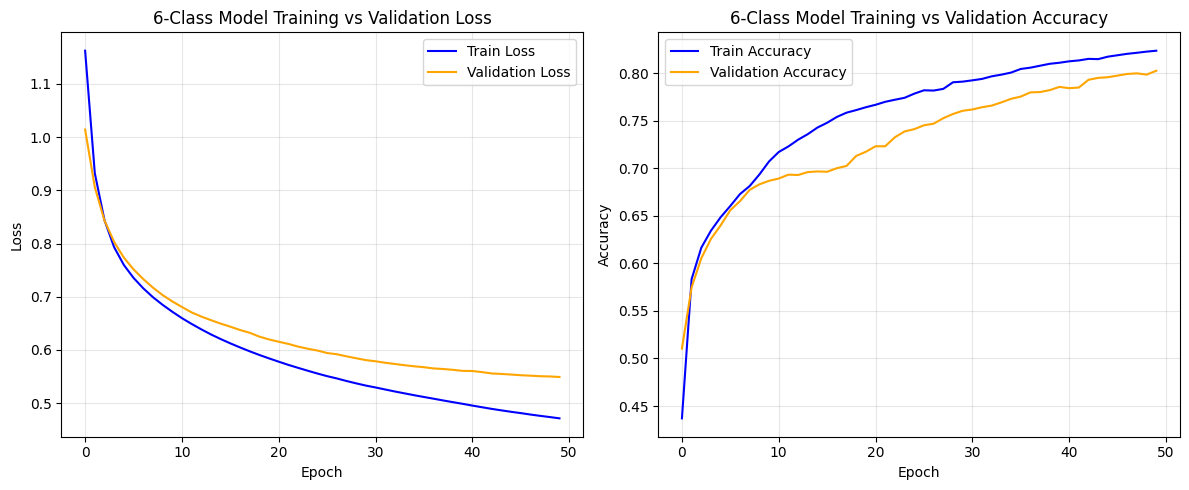

Saved: training_curves.png

6-Class Model Evaluation
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Classification Report:
              precision    recall  f1-score   support

     WALKING       0.86      0.84      0.85       496
  WALKING_UP       0.80      0.85      0.82       471
WALKING_DOWN       0.94      0.89      0.91       420
     SITTING       0.79      0.65      0.71       491
    STANDING       0.87      0.67      0.76       532
      LAYING       0.67      0.93      0.78       537

    accuracy                           0.80      2947
   macro avg       0.82      0.80      0.81      2947
weighted avg       0.82      0.80      0.80      2947



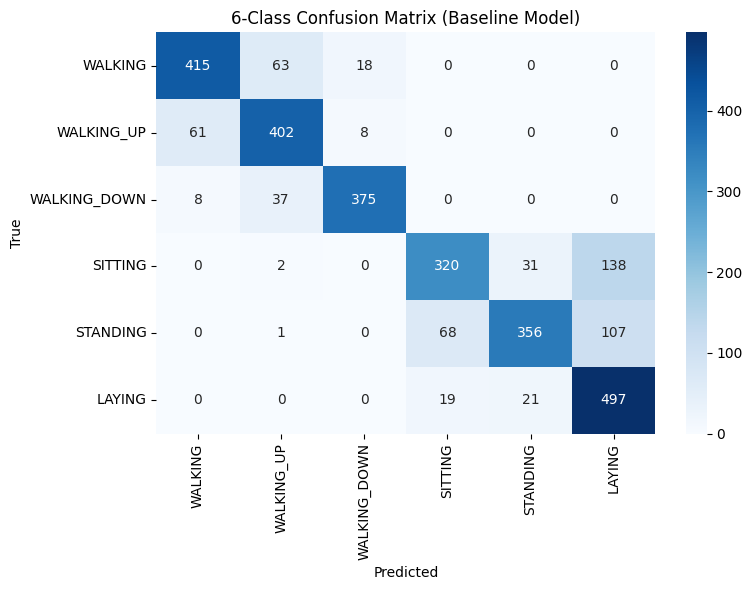

Saved: confusion_matrix.png

6-Class Model TFLite Conversion
Saved artifact at '/tmp/tmp4pi19p55'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28), dtype=tf.float32, name='keras_tensor_12')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  136240712182544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136240712187152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136240712181392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136240684916304: TensorSpec(shape=(), dtype=tf.resource, name=None)
Saved: complete_features_model.tflite
File size: 6.26 KB

Creating Reduced 2-Class Model
Original classes: [0 1 2 3 4 5]
Binary classes: [0 1]
Training samples: 7352
Test samples: 2947


Model: "reduced_features_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_hidden (Dense)            │ (None, 32)             │           928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_output (Dense)            │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 994 (3.88 KB)

 Trainable params: 994 (3.88 KB)

 Non-trainable params: 0 (0.00 B)


Training Reduced 2-Class Model
Epoch 1/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9732 - loss: 0.0973 - val_accuracy: 0.9966 - val_loss: 0.0192
Epoch 2/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9971 - loss: 0.0161 - val_accuracy: 0.9986 - val_loss: 0.0091
Epoch 3/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9988 - loss: 0.0064 - val_accuracy: 0.9993 - val_loss: 0.0060
Epoch 4/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9993 - loss: 0.0040 - val_accuracy: 0.9993 - val_loss: 0.0044
Epoch 5/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9997 - loss: 0.0031 - val_accuracy: 0.9993 - val_loss: 0.0035
Epoch 6/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9997 - loss: 0.0026 - val_accuracy: 0.9993 - val_loss: 0.0028
Epoch 7/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9999 - loss: 0.0023 - val_accuracy: 0.9993 - val_loss: 0.0023
Epoch 8/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9999 -

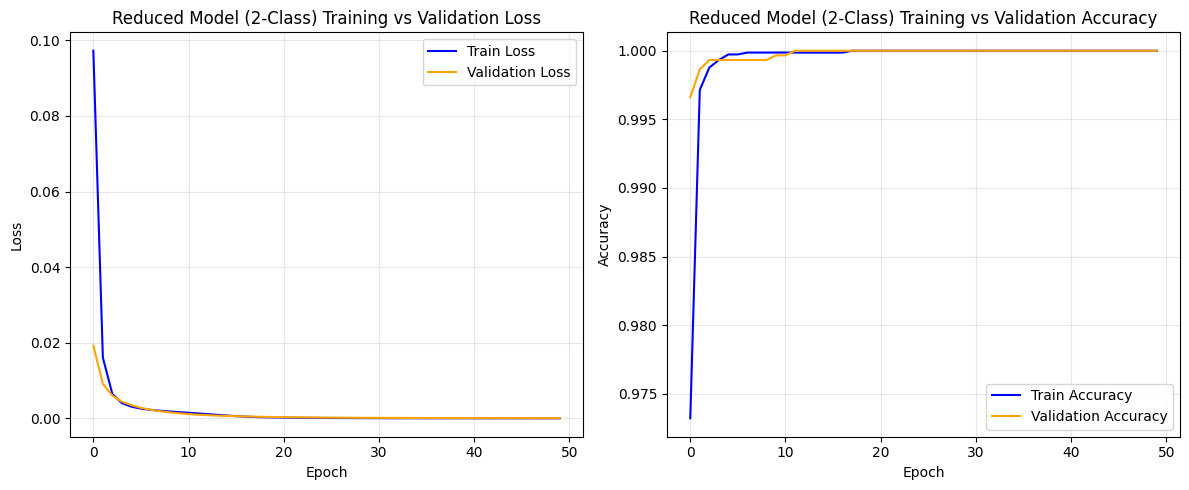

Saved: reduced_training_curves.png

Reduced Model (2-Class) Evaluation
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Classification Report (2-Class):
              precision    recall  f1-score   support

  STATIONARY       1.00      1.00      1.00      1560
     WALKING       1.00      1.00      1.00      1387

    accuracy                           1.00      2947
   macro avg       1.00      1.00      1.00      2947
weighted avg       1.00      1.00      1.00      2947



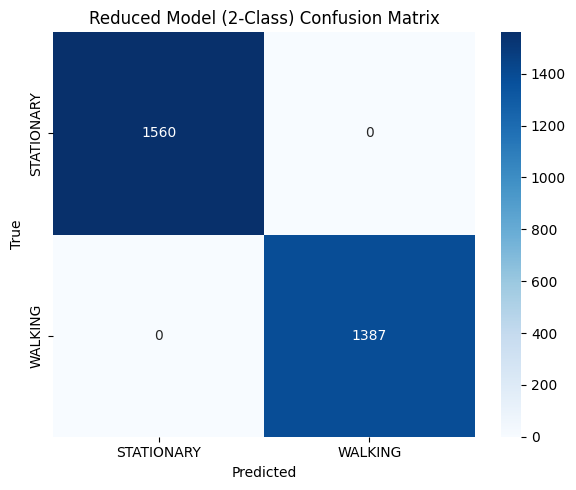

Saved: reduced_confusion_matrix.png

Saving Reduced Model and TFLite Conversion
Saved: reduced_features_baseline.keras
Saved artifact at '/tmp/tmpy_mj6e7d'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28), dtype=tf.float32, name='keras_tensor_15')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  136240568794000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136240568786896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136240571716944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136240571713680: TensorSpec(shape=(), dtype=tf.resource, name=None)
Saved: reduced_features_baseline.tflite
File size: 5.74 KB

Saving Scaler Configuration
Saved: scaler_params.json
Saved: scaler.pkl

Pipeline Complete - Summary Report

📁 OUTPUT DIRECTORY STRUCTURE:
├── full_model/
│   ├── models/
│   │   ├── complete_features_baseline.keras
│   │   └── complete_features_model.tflite
│   

In [3]:

# Final Summary Report

print("\n" + "="*60)
print("Pipeline Complete - Summary Report")
print("="*60)

print("\n📁 OUTPUT DIRECTORY STRUCTURE:")
print("├── full_model/")
print("│   ├── models/")
print("│   │   ├── complete_features_baseline.keras")
print("│   │   └── complete_features_model.tflite")
print("│   ├── training_curves.png")
print("│   └── confusion_matrix.png")
print("└── reduced/")
print("    ├── models/")
print("    │   ├── reduced_features_baseline.keras")
print("    │   ├── reduced_features_baseline.tflite")
print("    │   ├── scaler.pkl")
print("    │   └── scaler_params.json")
print("    ├── reduced_training_curves.png")
print("    └── reduced_confusion_matrix.png")

print("\n📊 MODEL PERFORMANCE SUMMARY:")
print(f"6-Class Model - Test Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"2-Class Model - Test Accuracy: {history_reduced.history['val_accuracy'][-1]:.4f}")

print("\n📦 MODEL FILE SIZES:")
print(f"6-Class TFLite: {os.path.getsize(tflite_path) / 1024:.2f} KB")
print(f"2-Class TFLite: {os.path.getsize(tflite_reduced_path) / 1024:.2f} KB")

print("\n✅ Pipeline completed successfully!")